# Módulo 40 — Exercício: Aplicando SVM

**Propensão de compra de carros** · Classificação binária (compra / não compra)

Atividade do curso **EBAC — Profissão: Cientista de Dados**. Usamos a base de propensão de compra de carros (a mesma da tarefa de XGBoost) para treinar SVMs com kernels `linear` e `poly`, e comparar com o XGBoost.

**Além do que o exercício pede**, este notebook:
- padroniza as variáveis dentro de uma `Pipeline` (SVM é sensível à escala) e mostra o que acontece sem isso;
- inclui o kernel `rbf` como comparação extra;
- compara os modelos também por validação cruzada, e não só por uma divisão treino/teste.

**Autor:** Talita Luci · [GitHub](https://github.com/TalitaLuci)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42

# Caminhos do projeto (funciona abrindo o notebook a partir de notebooks/ ou da raiz)
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_FILE = PROJECT_ROOT / 'data' / 'raw' / 'CARRO_CLIENTES.csv'

## 1. Carregar a base, verificar tipos, dados faltantes e remover a coluna ID

In [2]:
df = pd.read_csv(DATA_FILE, encoding='utf-8-sig')

print(df.shape)
df.head()

(1000, 5)


,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   User ID       1000 non-null   int64
 1   Gender        1000 non-null   str  
 2   Age           1000 non-null   int64
 3   AnnualSalary  1000 non-null   int64
 4   Purchased     1000 non-null   int64
dtypes: int64(4), str(1)
memory usage: 39.2 KB


In [4]:
# Verificando dados faltantes
df.isnull().sum()

User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

Não há dados faltantes e os tipos estão coerentes (`Gender` é texto; as demais colunas são numéricas). O `User ID` é só um identificador, sem valor preditivo, e é removido.

> Observação: existem 57 linhas com perfil idêntico (mesmo gênero, idade, salário e rótulo). Como as variáveis têm poucos valores distintos, isso é esperado e **não** indica erro, então nenhuma linha é removida.

In [5]:
print('Linhas com perfil repetido (ignorando o ID):', df.drop(columns=['User ID']).duplicated().sum())
df = df.drop(columns=['User ID'])
print('Proporção de compradores:', df['Purchased'].mean().round(3))
df.head()

Linhas com perfil repetido (ignorando o ID): 57
Proporção de compradores: 0.402


,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0


## 2. Label Encoder na coluna Gender e exclusão da coluna categórica

In [6]:
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])
print('Mapeamento:', dict(zip(le.classes_, le.transform(le.classes_))))

# Excluindo a coluna categórica original
df = df.drop(columns=['Gender'])
df.head()

Mapeamento: {'Female': np.int64(0), 'Male': np.int64(1)}


,Age,AnnualSalary,Purchased,Gender_encoded
0,35,20000,0,1
1,40,43500,0,1
2,49,74000,0,1
3,40,107500,1,1
4,25,79000,0,1


## 3. Matriz de correlação

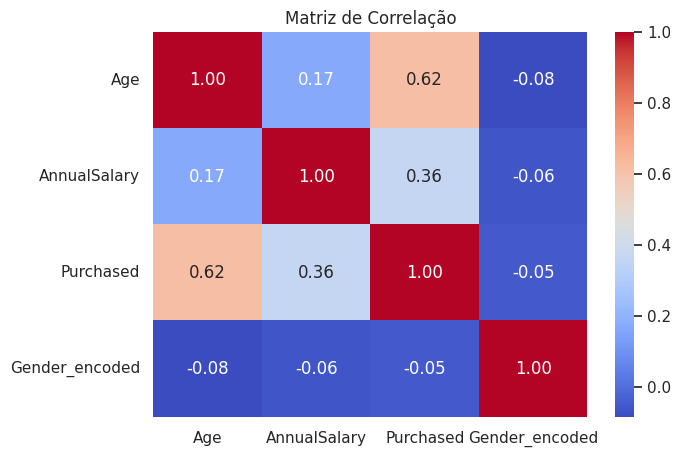

Purchased         1.000000
Age               0.616036
AnnualSalary      0.364974
Gender_encoded   -0.047211
Name: Purchased, dtype: float64

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

df.corr(numeric_only=True)['Purchased'].sort_values(ascending=False)

**Análise:** `Age` é a variável com maior correlação com `Purchased` (≈ 0,62), seguida por `AnnualSalary` (≈ 0,36). `Gender_encoded` praticamente não tem correlação com o alvo (≈ −0,05), sugerindo que o gênero pouco influencia a decisão de compra nesta base.

A correlação mede apenas relação **linear** entre duas variáveis. O gráfico abaixo mostra como `Age` e `AnnualSalary` se combinam: a região de compra não é um simples corte linear (isso será importante na comparação entre kernels).

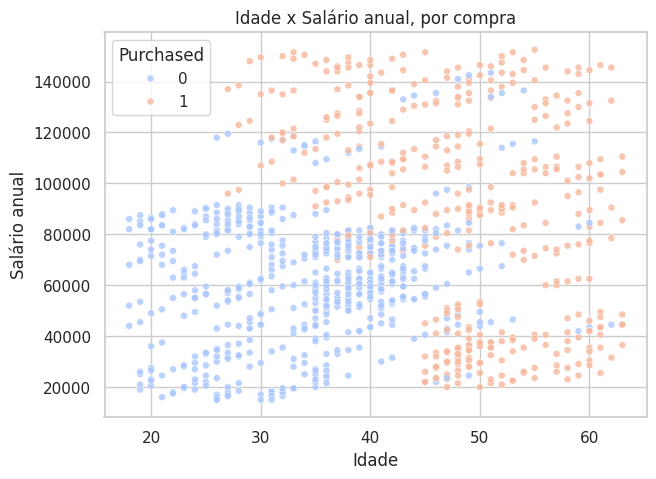

In [8]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Age', y='AnnualSalary', hue='Purchased', palette='coolwarm', s=25, alpha=0.8)
plt.title('Idade x Salário anual, por compra')
plt.xlabel('Idade'); plt.ylabel('Salário anual')
plt.show()

## 4. Separação em X / y e em treino / teste

In [9]:
X = df.drop(columns=['Purchased'])
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(X_train.shape, X_test.shape)

(750, 3) (250, 3)


## 5. SVM com kernel linear

**Padronização.** `Age` varia de ~18 a 63 e `AnnualSalary` de ~15 mil a ~150 mil. O SVM usa distâncias e produtos internos, então, sem padronizar, o salário domina o cálculo. Por isso treinamos uma `Pipeline` com `StandardScaler` + `SVC`; o scaler é ajustado apenas no treino. Uma função auxiliar repete a avaliação para todos os modelos.

In [10]:
def avaliar(modelo, nome, cmap='Blues'):
    """Imprime o relatório de classificação e plota a matriz de confusão no conjunto de teste."""
    pred = modelo.predict(X_test)
    print(f'Acurácia ({nome}): {accuracy_score(y_test, pred):.3f}\n')
    print(classification_report(y_test, pred))
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap=cmap,
                xticklabels=['Não compra', 'Compra'], yticklabels=['Não compra', 'Compra'])
    plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title(f'Matriz de Confusão - {nome}')
    plt.show()
    return pred


def svm_padronizado(kernel):
    return Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel=kernel, random_state=RANDOM_STATE))])


svm_linear = svm_padronizado('linear').fit(X_train, y_train)

## 6. Previsões e avaliação — kernel linear

Acurácia (SVM Linear): 0.828

              precision    recall  f1-score   support

           0       0.81      0.93      0.87       150
           1       0.86      0.68      0.76       100

    accuracy                           0.83       250
   macro avg       0.84      0.80      0.81       250
weighted avg       0.83      0.83      0.82       250



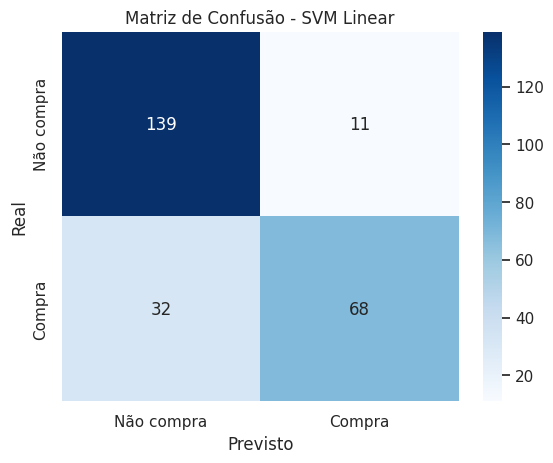

In [11]:
pred_linear = avaliar(svm_linear, 'SVM Linear', 'Blues')

**Análise:** o SVM linear (com padronização) atingiu **82,8%** de acurácia no teste. Ele identifica bem quem não compra (recall de 0,93 para a classe 0), mas deixa escapar cerca de um terço dos compradores (recall de **0,68** para a classe 1: 32 compradores classificados como "não compradores"). Em uma campanha de marketing, deixar de identificar um comprador potencial tem custo, então esse recall é o ponto fraco do modelo.

## 7. SVM com kernel poly — treino, previsões e avaliação

Acurácia (SVM Poly): 0.832

              precision    recall  f1-score   support

           0       0.81      0.94      0.87       150
           1       0.88      0.67      0.76       100

    accuracy                           0.83       250
   macro avg       0.85      0.80      0.82       250
weighted avg       0.84      0.83      0.83       250



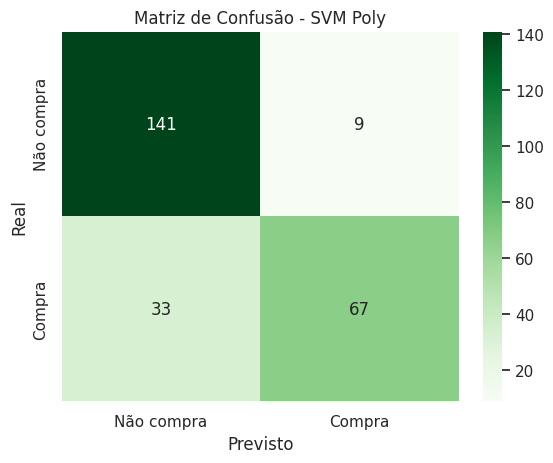

In [12]:
svm_poly = svm_padronizado('poly').fit(X_train, y_train)
pred_poly = avaliar(svm_poly, 'SVM Poly', 'Greens')

**Análise:** com padronização, o kernel `poly` obteve **83,2%** de acurácia, praticamente empatado com o linear (82,8%). A precisão para compradores é alta (0,88), mas o recall continua baixo (**0,67**): o modelo ainda deixa de identificar cerca de um terço dos compradores. O kernel polinomial de grau 3 (padrão) não captura bem a forma da região de compra.

### 7.1 O que acontece **sem** padronização?

A versão original do exercício treinava os SVMs direto nos dados brutos. Reproduzimos esse cenário para comparar (o SVM linear sem escala é bem mais lento, porque o problema de otimização fica mal condicionado).

In [13]:
import time

sem_escala = {
    'SVM linear (sem escala)': SVC(kernel='linear', random_state=RANDOM_STATE),
    'SVM poly (sem escala)': SVC(kernel='poly', random_state=RANDOM_STATE),
}
linhas = []
for nome, modelo in sem_escala.items():
    t0 = time.time()
    pred = modelo.fit(X_train, y_train).predict(X_test)
    linhas.append({'Modelo': nome, 'Acurácia': accuracy_score(y_test, pred),
                   'Recall (compra)': recall_score(y_test, pred), 'F1 (compra)': f1_score(y_test, pred),
                   'Tempo de treino (s)': time.time() - t0})
pd.DataFrame(linhas).set_index('Modelo').round(3)

,Acurácia,Recall (compra),F1 (compra),Tempo de treino (s)
Modelo,,,,
SVM linear (sem escala),0.824,0.72,0.766,33.755
SVM poly (sem escala),0.748,0.43,0.577,0.012


Sem padronização o kernel `poly` cai para **74,8%** de acurácia e **0,43** de recall, e o linear fica em 82,4%. A "piora" do `poly` vinha em grande parte da escala das variáveis, e não de a relação ser "quase linear": com padronização ele sobe para 83,2%.

## 8. Qual modelo se saiu melhor? Linear, poly, e o XGBoost da atividade anterior?

Além dos dois kernels pedidos, incluímos o **kernel `rbf`** (o mais usado na prática) e o XGBoost. Comparamos no conjunto de teste e também por **validação cruzada estratificada de 5 folds** na base inteira, que é mais confiável que um único sorteio de 250 linhas.

In [14]:
svm_rbf = svm_padronizado('rbf').fit(X_train, y_train)
xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss').fit(X_train, y_train)

modelos = {'SVM linear': svm_linear, 'SVM poly': svm_poly, 'SVM rbf': svm_rbf, 'XGBoost': xgb}

teste = pd.DataFrame({
    nome: {'Acurácia': accuracy_score(y_test, m.predict(X_test)),
           'Precisão': precision_score(y_test, m.predict(X_test)),
           'Recall': recall_score(y_test, m.predict(X_test)),
           'F1': f1_score(y_test, m.predict(X_test))}
    for nome, m in modelos.items()
}).T
print('Conjunto de teste (250 clientes):')
teste.round(3)

Conjunto de teste (250 clientes):


,Acurácia,Precisão,Recall,F1
SVM linear,0.828,0.861,0.68,0.760
SVM poly,0.832,0.882,0.67,0.761
SVM rbf,0.912,0.875,0.91,0.892
XGBoost,0.896,0.863,0.88,0.871


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
novos = {'SVM linear': svm_padronizado('linear'), 'SVM poly': svm_padronizado('poly'),
         'SVM rbf': svm_padronizado('rbf'),
         'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')}

linhas = {}
for nome, modelo in novos.items():
    r = cross_validate(modelo, X, y, cv=cv, scoring=['accuracy', 'recall', 'f1'])
    linhas[nome] = {'Acurácia (média)': r['test_accuracy'].mean(), 'Acurácia (desvio)': r['test_accuracy'].std(),
                    'Recall (média)': r['test_recall'].mean(), 'F1 (média)': r['test_f1'].mean()}
print('Validação cruzada (5 folds, base completa):')
pd.DataFrame(linhas).T.round(3)

Validação cruzada (5 folds, base completa):


,Acurácia (média),Acurácia (desvio),Recall (média),F1 (média)
SVM linear,0.826,0.027,0.704,0.764
SVM poly,0.842,0.022,0.724,0.786
SVM rbf,0.903,0.019,0.903,0.882
XGBoost,0.881,0.023,0.861,0.853


Para entender **por que** os resultados diferem, veja as regiões de decisão de cada kernel no plano idade × salário (com gênero fixo, já que ele quase não influencia):

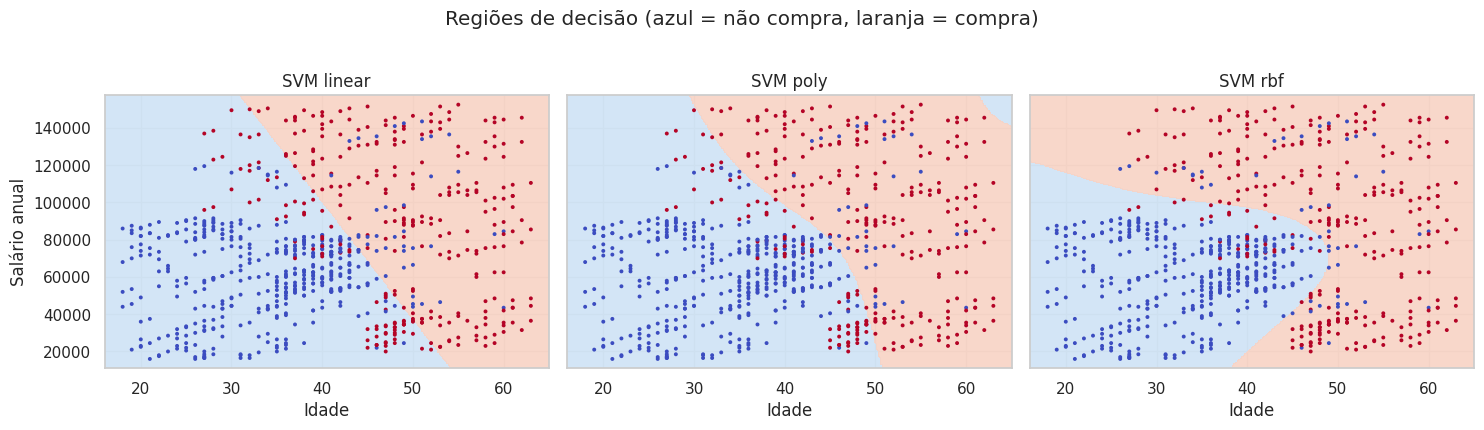

In [16]:
age = np.linspace(X_train['Age'].min() - 2, X_train['Age'].max() + 2, 250)
sal = np.linspace(X_train['AnnualSalary'].min() - 5000, X_train['AnnualSalary'].max() + 5000, 250)
A, S = np.meshgrid(age, sal)
grade = pd.DataFrame({'Age': A.ravel(), 'AnnualSalary': S.ravel(), 'Gender_encoded': 0})[X_train.columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (nome, m) in zip(axes, {k: v for k, v in modelos.items() if k.startswith('SVM')}.items()):
    Z = m.predict(grade).reshape(A.shape)
    ax.contourf(A, S, Z, levels=[-0.5, 0.5, 1.5], colors=['#cfe3f5', '#f8d3c5'], alpha=0.9)
    ax.scatter(X_train['Age'], X_train['AnnualSalary'], c=y_train, cmap='coolwarm', s=8, edgecolor='none')
    ax.set_title(nome); ax.set_xlabel('Idade')
axes[0].set_ylabel('Salário anual')
fig.suptitle('Regiões de decisão (azul = não compra, laranja = compra)', y=1.02)
plt.tight_layout(); plt.show()

**Resposta:**

Entre os dois kernels pedidos, **linear e poly ficam praticamente empatados** quando as variáveis são padronizadas (teste: 82,8% vs 83,2%; validação cruzada: 82,6% vs 84,2%). Nos dois, o recall da classe "compra" fica em torno de 0,67–0,72, ou seja, ~30% dos compradores não são identificados. O resultado muito pior do `poly` na versão sem padronização (74,8%) era efeito da escala das variáveis.

Comparando com o **XGBoost da atividade anterior** (teste: 89,6%; CV: 88,1%), ele supera os dois SVMs pedidos por boa margem, o que confirma o resultado original.

Porém, o gráfico das regiões de decisão mostra que a fronteira real **não é linear**: a taxa de compra salta de 29% (41–45 anos) para 77% (46–48 anos) e chega a 95% acima de 55 anos, quase independente do salário, enquanto entre os menores de 40 anos a compra depende do salário (0% abaixo de R$ 60 mil, 79% acima de R$ 100 mil). O **SVM com kernel `rbf`**, que consegue desenhar essa fronteira curva, chega a **91,2% no teste** e **90,3% na validação cruzada**, com recall de ~0,90, **superando o próprio XGBoost** (89,6% / 88,1%). Na validação cruzada a diferença do `rbf` para o XGBoost é de ~2 pontos percentuais, com desvio-padrão de ~2 p.p. em cada um, então o ganho é consistente na direção, mas pequeno.

**Ranking final (validação cruzada):** SVM rbf (0,903) > XGBoost (0,881) > SVM poly (0,842) > SVM linear (0,826).

**Conclusão:** o problema não pede "um modelo mais complexo", e sim um kernel adequado ao formato da fronteira. Um SVM bem configurado (padronizado + `rbf`) bate o XGBoost padrão nesta base, que tem só 3 variáveis e 1.000 linhas. Como próximos passos, vale ajustar `C` e `gamma` do `rbf` e os hiperparâmetros do XGBoost com `GridSearchCV` antes de declarar um vencedor definitivo.